# Hypo3 Relation: Macro Factors vs GPU / CPU / RAM

목적: 개별 macro factor가 GPU, CPU, RAM 주간 로그수익률과 현재 시점에서 관련이 있는지 factor별 통제변수를 다르게 적용해 검정한다.

- `SOXX`는 single-stock proxy보다 넓은 반도체/AI 수요 proxy로 사용한다.
- 따라서 다른 회귀식에서도 AI/반도체 수요 통제는 `SOXX`로 둔다.
- 분기 더미 없음
- hardware 자기시차 없음
- macro lag / distributed lag 없음
- 구조적 첫 결측은 분리하고, 이후 내부 결측은 회귀식별 complete-case로 처리
- 저장 파일은 최소화: `data.csv`, `miss.csv`, `res.csv`와 핵심 plot 4개만 저장


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

out = Path("outputs/hypo3_relation")
pic = Path("output_pic/hypo3_relation")
out.mkdir(parents=True, exist_ok=True)
pic.mkdir(parents=True, exist_ok=True)

ret_path = Path("outputs/ret_all_w.csv")
if not ret_path.exists():
    ret_path = Path("ret_all_w.csv")

week = "W-SUN"
hws = ["GPU", "CPU", "RAM"]

plt.rcParams["axes.unicode_minus"] = False


def z(s):
    return (s - s.mean()) / s.std()


def fig(name):
    p = pic / name
    plt.savefig(p, dpi=300, bbox_inches="tight")
    print("saved:", p)

## 1. Hardware return load
`ret_all_w.csv`는 기존 EDA에서 만든 Chain Matched Jevons 주간 로그수익률 결과를 그대로 사용한다.

In [2]:
ret = pd.read_csv(ret_path, parse_dates=["date"]).set_index("date").sort_index()
ret = ret[["GPU_ALL", "CPU_ALL", "RAM_ALL"]].rename(columns={
    "GPU_ALL": "gpu_ret",
    "CPU_ALL": "cpu_ret",
    "RAM_ALL": "ram_ret",
})

print("loaded:", ret_path)
display(ret.head())
print(ret.shape)

loaded: outputs\ret_all_w.csv


,gpu_ret,cpu_ret,ram_ret
date,,,
2024-03-03,NaN,NaN,NaN
2024-03-10,0.002189,-0.001478,0.002896
2024-03-17,0.003092,0.000508,0.001473
2024-03-24,0.002050,0.000673,-0.003016
2024-03-31,0.001093,0.001044,-0.001508


(110, 3)


## 2. Market and macro data
시장 가격형 변수는 주간 마지막 관측값 기준 로그수익률로 변환한다. `CSI`는 level이므로 주간 forward-fill 후 변화량(`csi_chg`)을 사용한다. `SOXX`는 넓은 반도체/AI 수요 proxy로 쓰며 single-stock proxy는 별도 통제변수로 사용하지 않는다.


In [3]:
st = ret.index.min() - pd.Timedelta(days=14)
ed = ret.index.max() + pd.Timedelta(days=7)

tick = {
    "BTC-KRW": "btc",
    "KRW=X": "fx",
    "SOXX": "soxx",
    "BZ=F": "oil",
}

px = yf.download(list(tick.keys()), start=st, end=ed, auto_adjust=True, progress=False)["Close"]
px = px.rename(columns=tick)
wk = px.resample(week).last()

mkt = np.log(wk).diff().rename(columns={
    "btc": "btc_ret",
    "fx": "fx_ret",
    "soxx": "soxx_ret",
    "oil": "oil_ret",
})

csi = web.DataReader("UMCSENT", "fred", st, ed).rename(columns={"UMCSENT": "csi"})
mkt = mkt.join(csi.resample(week).ffill(), how="left")
mkt["csi_chg"] = mkt["csi"].diff()

display(mkt.head())


,btc_ret,oil_ret,fx_ret,soxx_ret,csi,csi_chg
Date,,,,,,
2024-02-18,NaN,NaN,NaN,NaN,NaN,NaN
2024-02-25,-0.008670,NaN,NaN,NaN,NaN,NaN
2024-03-03,0.200368,0.023371,0.006032,0.06592,79.4,NaN
2024-03-10,0.077409,-0.017751,-0.010556,0.00667,79.4,0.0
2024-03-17,0.001036,0.038949,0.000560,-0.04194,79.4,0.0


## 3. Merge and standardize
`data.csv` 하나에 회귀에 필요한 원자료와 표준화 변수를 함께 저장한다. 전체 `dropna()`는 하지 않고, 결측 처리는 각 회귀식 내부에서 필요한 변수 기준으로만 수행한다.

In [4]:
df = ret.join(mkt, how="inner").sort_index()
raw = ["btc_ret", "fx_ret", "soxx_ret", "oil_ret", "csi_chg"]
for c in raw:
    df[c + "_z"] = z(df[c])

df.to_csv(out / "data.csv")

na = round(df[raw].isna().sum() / len(df) * 100, 2)
print("missing rate (%)")
display(na)
print("saved:", out / "data.csv")


missing rate (%)


btc_ret     0.00
fx_ret      0.00
soxx_ret    0.00
oil_ret     0.00
csi_chg     0.91
dtype: float64

saved: outputs\hypo3_relation\data.csv


## 4. Factor-specific control sets
통제변수는 factor별로 다르게 둔다. `SOXX`는 넓은 반도체/AI 수요 proxy이므로, BTC/Oil/CSI 회귀에서 AI 수요 통제는 `SOXX`로 둔다. 단, `SOXX` 자체를 검정할 때는 자기 자신을 통제변수로 넣지 않는다.


In [5]:
spec = {
    "BTC":  ["btc_ret_z",  ["fx_ret_z", "soxx_ret_z"]],
    "SOXX": ["soxx_ret_z", ["fx_ret_z", "btc_ret_z"]],
    "Oil":  ["oil_ret_z",  ["fx_ret_z", "btc_ret_z", "soxx_ret_z"]],
    "CSI":  ["csi_chg_z",  ["fx_ret_z", "btc_ret_z", "soxx_ret_z", "oil_ret_z"]],
}

pd.DataFrame([
    {"factor": k, "x": v[0], "ctrl": ", ".join(v[1])}
    for k, v in spec.items()
])


,factor,x,ctrl
0,BTC,btc_ret_z,"fx_ret_z, soxx_ret_z"
1,SOXX,soxx_ret_z,"fx_ret_z, btc_ret_z"
2,Oil,oil_ret_z,"fx_ret_z, btc_ret_z, soxx_ret_z"
3,CSI,csi_chg_z,"fx_ret_z, btc_ret_z, soxx_ret_z, oil_ret_z"


## 5. Controlled regressions
첫 결측은 로그수익률/차분 정의상 생기는 구조적 결측으로 분리한다. 이후 남는 내부 결측은 MCAR로 보고, 각 회귀식에서 실제 사용하는 변수 기준으로 complete-case 처리한다.

In [6]:
def cut(d, cols):
    st0 = max(d[c].first_valid_index() for c in cols)
    body = d.loc[st0:].copy()
    mc = body[body[cols].isna().any(axis=1)]
    use = body.dropna(subset=cols)
    return use, st0, len(d.loc[:st0].iloc[:-1]), len(mc)


def vmax(d, xs):
    X = sm.add_constant(d[xs])
    v = [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]
    return max(v)


def fit(y, fac):
    x, ctrl = spec[fac]
    xs = [x] + ctrl
    cols = [y] + xs
    d, st0, n0, n1 = cut(df[cols], cols)

    form = y + " ~ " + " + ".join(xs)
    m = smf.ols(form, data=d).fit(cov_type="HC3")
    r = smf.ols(y + " ~ " + " + ".join(ctrl), data=d).fit(cov_type="HC3")
    pr2 = (m.rsquared - r.rsquared) / (1 - r.rsquared)

    return {
        "hw": y[:3].upper(),
        "factor": fac,
        "x": x,
        "ctrl": ", ".join(ctrl),
        "n": int(m.nobs),
        "coef": m.params[x],
        "se": m.bse[x],
        "t": m.tvalues[x],
        "p": m.pvalues[x],
        "r2": m.rsquared,
        "pr2": pr2,
        "max_vif": vmax(d, xs),
        "start": st0,
        "struct_na": n0,
        "mcar_na": n1,
        "model": form,
    }

ys = ["gpu_ret", "cpu_ret", "ram_ret"]
rows = [fit(y, f) for y in ys for f in spec]
res = pd.DataFrame(rows)
miss = res[["hw", "factor", "start", "struct_na", "mcar_na", "n"]].copy()

res.to_csv(out / "res.csv", index=False)
miss.to_csv(out / "miss.csv", index=False)

display(res.round(5))
print("saved:", out / "res.csv", out / "miss.csv")

,hw,factor,x,ctrl,n,coef,se,t,p,r2,pr2,max_vif,start,struct_na,mcar_na,model
0,GPU,BTC,btc_ret_z,"fx_ret_z, soxx_ret_z",105,-0.00258,0.00154,-1.67221,0.09448,0.07986,0.06710,1.10373,2024-03-10,1,4,gpu_ret ~ btc_ret_z + fx_ret_z + soxx_ret_z
1,GPU,SOXX,soxx_ret_z,"fx_ret_z, btc_ret_z",105,0.00094,0.00069,1.36248,0.17305,0.07986,0.01028,1.10373,2024-03-10,1,4,gpu_ret ~ soxx_ret_z + fx_ret_z + btc_ret_z
2,GPU,Oil,oil_ret_z,"fx_ret_z, btc_ret_z, soxx_ret_z",105,0.00068,0.00153,0.44447,0.65671,0.08477,0.00534,1.15633,2024-03-10,1,4,gpu_ret ~ oil_ret_z + fx_ret_z + btc_ret_z + s...
3,GPU,CSI,csi_chg_z,"fx_ret_z, btc_ret_z, soxx_ret_z, oil_ret_z",105,-0.00028,0.00074,-0.38044,0.70362,0.08565,0.00096,1.19404,2024-03-10,1,4,gpu_ret ~ csi_chg_z + fx_ret_z + btc_ret_z + s...
4,CPU,BTC,btc_ret_z,"fx_ret_z, soxx_ret_z",105,0.00021,0.00048,0.43594,0.66288,0.01048,0.00121,1.10373,2024-03-10,1,4,cpu_ret ~ btc_ret_z + fx_ret_z + soxx_ret_z
5,CPU,SOXX,soxx_ret_z,"fx_ret_z, btc_ret_z",105,-0.00006,0.00042,-0.14970,0.88100,0.01048,0.00012,1.10373,2024-03-10,1,4,cpu_ret ~ soxx_ret_z + fx_ret_z + btc_ret_z
6,CPU,Oil,oil_ret_z,"fx_ret_z, btc_ret_z, soxx_ret_z",105,0.00050,0.00053,0.95734,0.33840,0.01780,0.00740,1.15633,2024-03-10,1,4,cpu_ret ~ oil_ret_z + fx_ret_z + btc_ret_z + s...
7,CPU,CSI,csi_chg_z,"fx_ret_z, btc_ret_z, soxx_ret_z, oil_ret_z",105,-0.00011,0.00066,-0.16864,0.86608,0.01818,0.00038,1.19404,2024-03-10,1,4,cpu_ret ~ csi_chg_z + fx_ret_z + btc_ret_z + s...
8,RAM,BTC,btc_ret_z,"fx_ret_z, soxx_ret_z",105,-0.00357,0.00278,-1.28363,0.19927,0.02763,0.01803,1.10373,2024-03-10,1,4,ram_ret ~ btc_ret_z + fx_ret_z + soxx_ret_z
9,RAM,SOXX,soxx_ret_z,"fx_ret_z, btc_ret_z",105,0.00339,0.00175,1.94351,0.05196,0.02763,0.01767,1.10373,2024-03-10,1,4,ram_ret ~ soxx_ret_z + fx_ret_z + btc_ret_z


saved: outputs\hypo3_relation\res.csv outputs\hypo3_relation\miss.csv


## 6. Plots
필요한 그림만 저장한다: 상관행렬, 통제 후 계수, partial R², 산점도 행렬.

saved: output_pic\hypo3_relation\01_corr.png


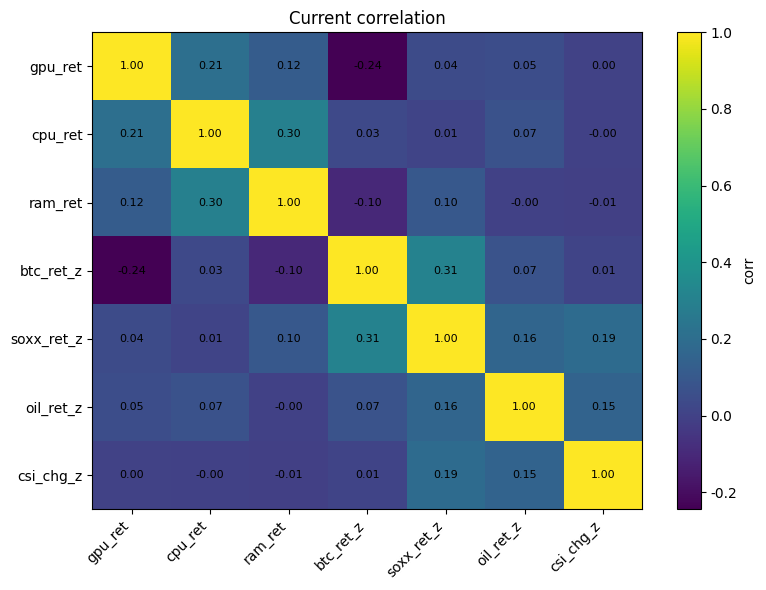

saved: output_pic\hypo3_relation\02_coef.png


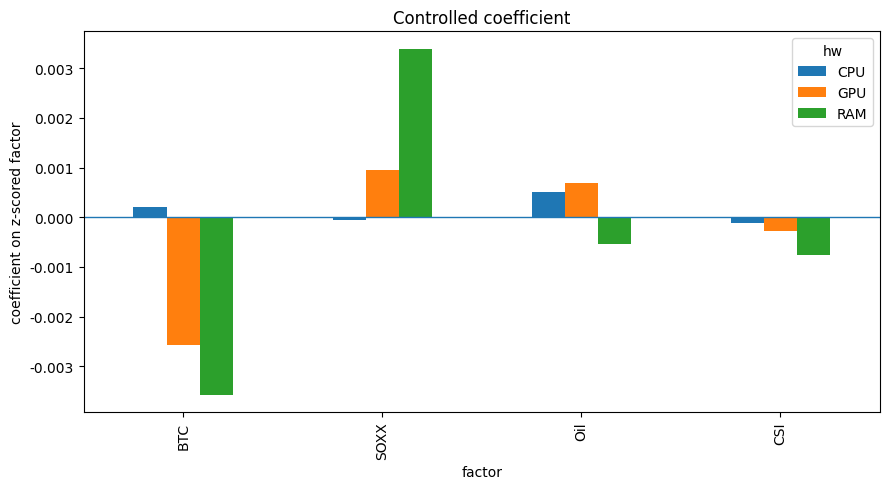

saved: output_pic\hypo3_relation\03_pr2.png


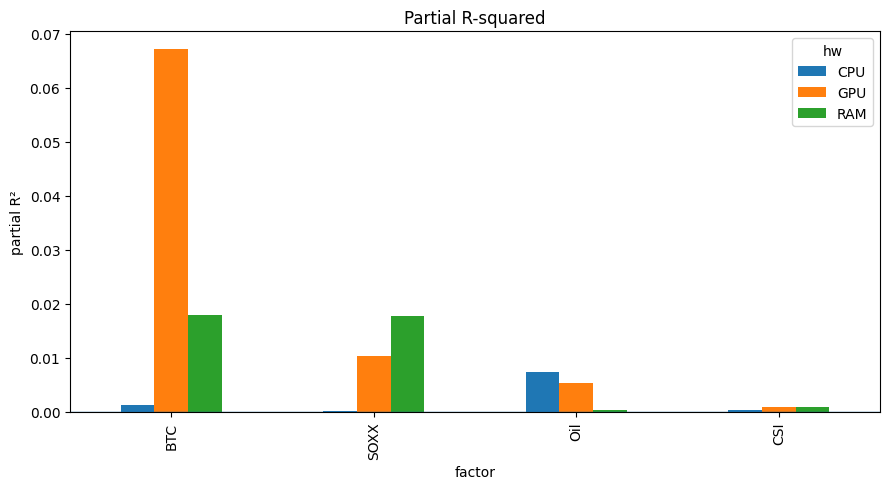

In [7]:
# 1) correlation matrix
cc = ["gpu_ret", "cpu_ret", "ram_ret"] + [spec[k][0] for k in spec]
C = df[cc].corr()

plt.figure(figsize=(8, 6))
plt.imshow(C, aspect="auto")
plt.colorbar(label="corr")
plt.xticks(range(len(C.columns)), C.columns, rotation=45, ha="right")
plt.yticks(range(len(C.index)), C.index)
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        plt.text(j, i, f"{C.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("Current correlation")
plt.tight_layout()
fig("01_corr.png")
plt.show()

# 2) controlled coefficient
pv = res.pivot(index="factor", columns="hw", values="coef").loc[list(spec.keys())]
ax = pv.plot(kind="bar", figsize=(9, 5))
plt.axhline(0, linewidth=1)
plt.title("Controlled coefficient")
plt.ylabel("coefficient on z-scored factor")
plt.xlabel("factor")
plt.tight_layout()
fig("02_coef.png")
plt.show()

# 3) partial R2
pv = res.pivot(index="factor", columns="hw", values="pr2").loc[list(spec.keys())]
ax = pv.plot(kind="bar", figsize=(9, 5))
plt.axhline(0, linewidth=1)
plt.title("Partial R-squared")
plt.ylabel("partial R²")
plt.xlabel("factor")
plt.tight_layout()
fig("03_pr2.png")
plt.show()

saved: output_pic\hypo3_relation\04_scatter.png


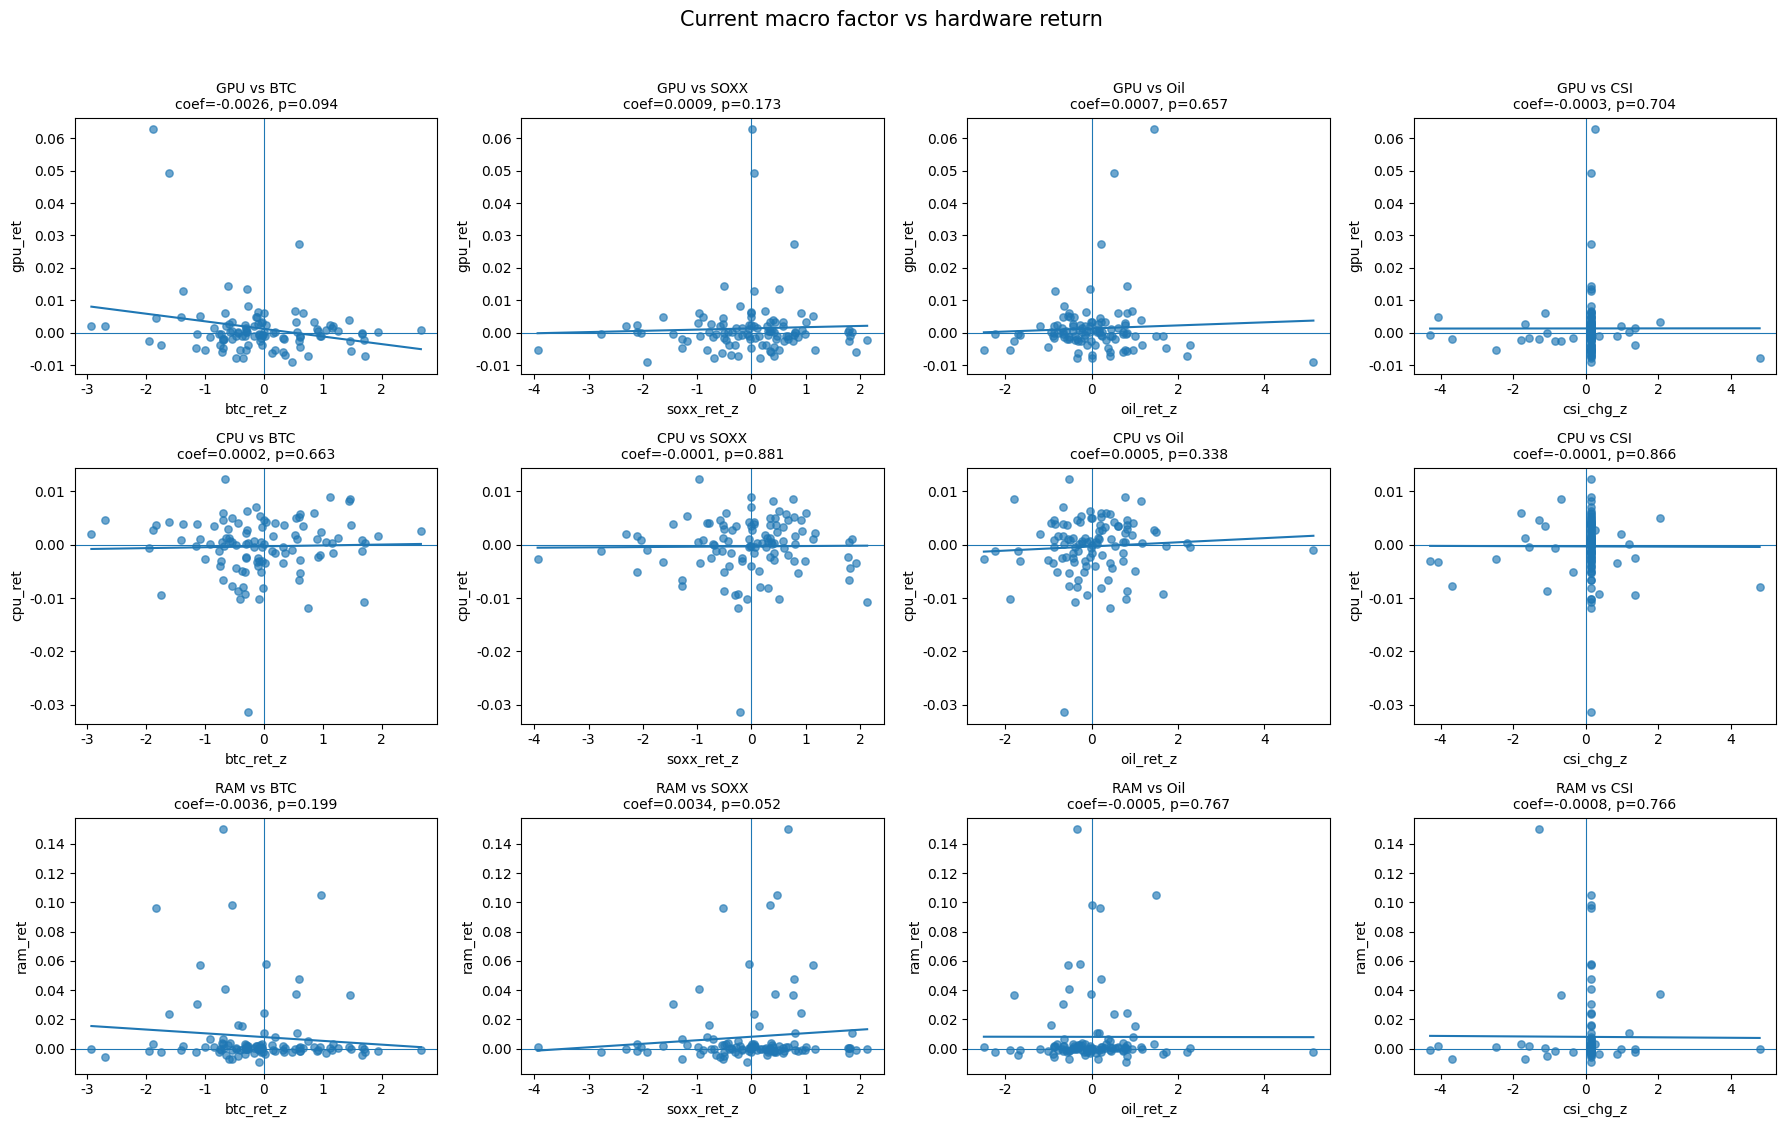

In [8]:
# 4) scatter matrix; title reports controlled regression p-value
fig0, ax = plt.subplots(3, 4, figsize=(18, 11))
ys = ["gpu_ret", "cpu_ret", "ram_ret"]
ylab = ["GPU", "CPU", "RAM"]
facs = list(spec.keys())

for i, y in enumerate(ys):
    for j, fac in enumerate(facs):
        a = ax[i, j]
        x = spec[fac][0]
        tmp = df[[y, x]].dropna()
        a.scatter(tmp[x], tmp[y], s=28, alpha=0.65)
        if len(tmp) >= 3:
            b1, b0 = np.polyfit(tmp[x], tmp[y], 1)
            xx = np.linspace(tmp[x].min(), tmp[x].max(), 50)
            a.plot(xx, b1 * xx + b0, linewidth=1.5)
        rr = res[(res["hw"] == ylab[i]) & (res["factor"] == fac)].iloc[0]
        a.set_title(f"{ylab[i]} vs {fac}\ncoef={rr.coef:.4f}, p={rr.p:.3f}", fontsize=10)
        a.set_xlabel(x)
        a.set_ylabel(y)
        a.axhline(0, linewidth=0.8)
        a.axvline(0, linewidth=0.8)

plt.suptitle("Current macro factor vs hardware return", y=1.02, fontsize=15)
plt.tight_layout()
fig("04_scatter.png")
plt.show()

## 7. Quick audit
이 셀은 저장 파일과 모델 설정을 확인하기 위한 점검용이다. 추가 파일은 저장하지 않는다.

In [ ]:
print("saved csv:", sorted(p.name for p in out.glob("*.csv")))
print("saved png:", sorted(p.name for p in pic.glob("*.png")))
print("current-period regressions only")
print("SOXX is used as broad semiconductor/AI proxy; single-stock proxy is not used")
print("no quarter dummy or hardware autoregressive regressor is used")
